In [1]:
import os
import yaml
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import BoundaryNorm
from PIL import Image

from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection, infer_device
from ultralytics import SAM

from torch.utils.data import Dataset
from torchvision import transforms


In [2]:
def generate_full_body_mask(image_path, text_prompt):
    # Load Grounding DINO Model and Generate bounding box
    image = Image.open(image_path).convert("RGB")
    text_labels = [[text_prompt]]
    model_id = "IDEA-Research/grounding-dino-base"
    device = infer_device()
    processor = AutoProcessor.from_pretrained(model_id)
    model_dino = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)
    inputs = processor(images=image, text=text_labels, return_tensors="pt").to(model_dino.device)
    with torch.no_grad():
        outputs = model_dino(**inputs)
    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.35,
        text_threshold=0.25,
        target_sizes=[image.size[::-1]]
    )
    box = results[0]['boxes'][0].cpu().numpy()

    # Load a model
    model_sam2 = SAM("sam2.1_b.pt")
    results = model_sam2(image_path, bboxes=box)
    mask = results[0].masks.data.detach().cpu().numpy()
    mask_np = np.squeeze(mask)
    mask_binary = (mask_np > 0.5).astype(np.uint8)

    # Generate mask
    image_np = np.array(image)
    image_mask = np.ones_like(image_np)
    image_mask[mask.squeeze(0)==1] = image_np[mask.squeeze(0)==1]
    # plt.imshow(image_mask)

    return mask_binary, image_mask


image 1/1 /home/c/choton/beemachine/datasets/dataset_small/Bombus_affinis/108QD0GQRSRKTK8KDKGKAK4K1KIKAKWQHSXKTK1QO01QLSEQ10WQDKVQY0UQRS2QNKRKAK4KLS1QLSNQCKVQHS5KJ08K.jpg: 1024x1024 1 0, 123.7ms
Speed: 6.0ms preprocess, 123.7ms inference, 8.9ms postprocess per image at shape (1, 3, 1024, 1024)


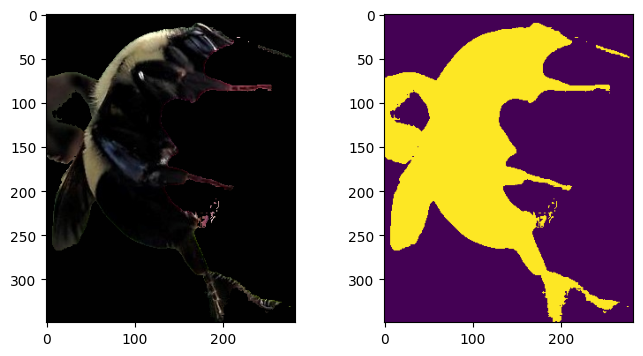

In [3]:
# Image path for zero-shot analysis
image_path = r"/home/c/choton/beemachine/datasets/dataset_small/Bombus_affinis/108QD0GQRSRKTK8KDKGKAK4K1KIKAKWQHSXKTK1QO01QLSEQ10WQDKVQY0UQRS2QNKRKAK4KLS1QLSNQCKVQHS5KJ08K.jpg"
text_prompt = r"bee"

mask, masked_image = generate_full_body_mask(image_path, text_prompt)
fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(masked_image)
axes[1].imshow(mask)

In [4]:
# Paths
DATA_DIR = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/"
yaml_path = os.path.join(DATA_DIR, 'data.yaml') # "/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/data.yaml"
images_dir = os.path.join(DATA_DIR, 'train', 'aug_images') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/images"
yolo_labels_dir = os.path.join(DATA_DIR, 'train', 'aug_labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/LABELS"
images = os.listdir(images_dir) # Get the list of images
images.sort() # Sorting images based on the name

In [9]:
def get_spectrum_colors(class_ids, cmap_name="viridis"):
    class_ids = sorted(class_ids)
    cmap = plt.get_cmap(cmap_name)
    n = len(class_ids)

    return {
        cid: cmap(i / max(n - 1, 1))[:3]  # drop alpha
        for i, cid in enumerate(class_ids)
    }

# Load class names from YAML
with open(yaml_path, 'r') as file:
    # Use safe_load for security, as it prevents arbitrary code execution
    config = yaml.safe_load(file)
print(config)
LABELS = config['names']
if 'background' not in LABELS:
    LABELS.insert(0, 'background')
print(LABELS)
CLASS_COLORS = get_spectrum_colors(range(len(LABELS)), "turbo")

# Function to plot mask annotation
def plot_mask_annotation(image, mask, ax, labels=LABELS, class_colors=CLASS_COLORS):
    np.random.seed(30) # Same color everytime
    mask_np = np.array(mask)
    ax.set_title("Fixed mask annotations")
    ax.imshow(image)
    class_ids = np.unique(mask_np)
    # class_ids = class_ids[class_ids != 0]    
    color_mask = np.zeros((*mask_np.shape, 3), dtype=float)
    for cid in class_ids:
        color_mask[mask_np == cid] = class_colors[cid]
    ax.imshow(color_mask, alpha=0.5)    
    for cid in class_ids:
        ax.plot([], [], color=class_colors[cid], label=f"{cid}: {labels[cid]}")
    ax.legend()

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['abdomen', 'head', 'thorax'], 'roboflow': {'workspace': 'test-f3zdy', 'project': 'beemachine-aqnj1', 'version': 10, 'license': 'MIT', 'url': 'https://universe.roboflow.com/test-f3zdy/beemachine-aqnj1/dataset/10'}}
['background', 'abdomen', 'head', 'thorax']


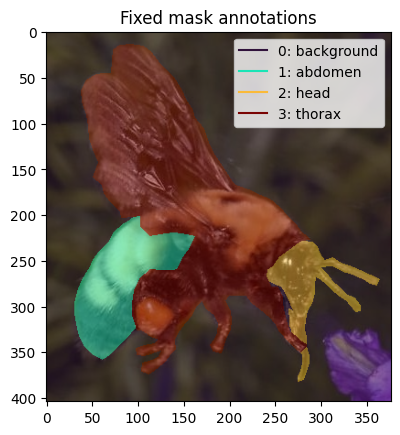

In [10]:
fig, axes = plt.subplots(1, 1)
image_file = images[204]
image_path = os.path.join(images_dir, image_file)
mask_path = os.path.join(DATA_DIR, 'train', 'aug_masks', image_file[:-4] + "_m.png")
image = Image.open(image_path)
mask = Image.open(mask_path).convert("L")  # class-index mask
plot_mask_annotation(image, mask, axes)

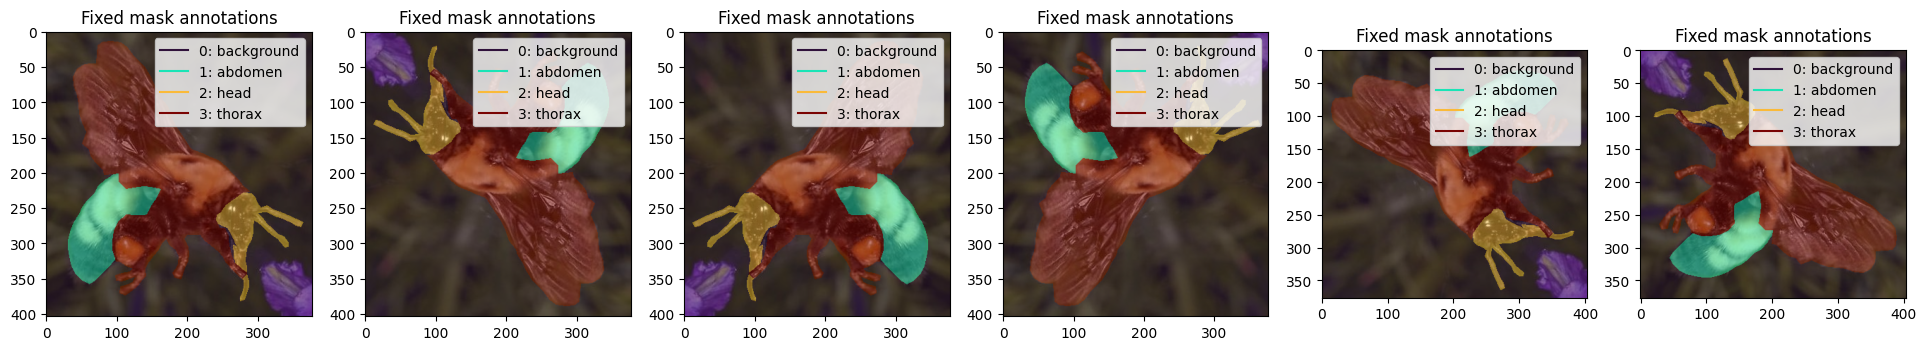

In [11]:
fig, axes = plt.subplots(1, 6, figsize=(24,4))
for i in range(6):
    image_file = images[204+i]
    image_path = os.path.join(images_dir, image_file)
    mask_path = os.path.join(DATA_DIR, 'train', 'aug_masks', image_file[:-4] + "_m.png")
    image = Image.open(image_path)
    mask = Image.open(mask_path).convert("L")  # class-index mask
    plot_mask_annotation(image, mask, axes[i])


image 1/1 /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/train/aug_images/0H6RLHERTZIZ2LZZ6LHZDL0ZDLXZULIRYZ0RJZHZULIRWLJL6L3L9LKRFZ3LFZHZDLGRVL8RBLMZVLKZQH8ROZZZPLXR_jpg.rf.53548c741ac8c0ce3acd244f08b8cb58_flip_h.jpg: 1024x1024 1 0, 85.9ms
Speed: 10.8ms preprocess, 85.9ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)


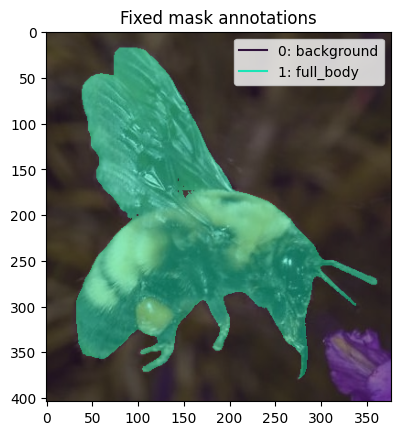

In [13]:
fig, axes = plt.subplots(1, 1)
image_file = images[204]
image_path = os.path.join(images_dir, image_file)
image = Image.open(image_path)
mask, masked_image = generate_full_body_mask(image_path, text_prompt)
plot_mask_annotation(image, mask, axes, labels=['background','full_body'])